# Forecasting Models Evaluation Analysis
## Comparing Chronax vs StatsForecast Libraries

This notebook analyzes and visualizes the performance of various forecasting models across two libraries.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# Set style for better-looking plots
#plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Data Loading and Cleaning Functions

In [3]:
def load_and_clean_data(file_path=None, data_string=None):
    """
    Load data from file or string and perform initial cleaning.
    
    Parameters:
    -----------
    file_path : str, optional
        Path to CSV file
    data_string : str, optional
        Raw data as string
    
    Returns:
    --------
    pd.DataFrame : Cleaned dataframe
    """
    # Load data - try different separators
    if file_path:
        # First, try to detect the separator
        with open(file_path, 'r') as f:
            first_line = f.readline()
        
        # Check if it's tab or comma separated
        if '\t' in first_line:
            df = pd.read_csv(file_path, sep='\t')
        else:
            df = pd.read_csv(file_path)
    elif data_string:
        if '\t' in data_string.split('\n')[0]:
            df = pd.read_csv(StringIO(data_string), sep='\t')
        else:
            df = pd.read_csv(StringIO(data_string))
    else:
        raise ValueError("Either file_path or data_string must be provided")
    
    # Print columns to debug
    print(f"\nColumns found: {df.columns.tolist()}")
    print(f"Shape before cleaning: {df.shape}")
    
    # Remove completely empty rows
    df = df.dropna(how='all')
    
    # Check if 'Model' column exists
    if 'Model' not in df.columns:
        print(f"\nError: 'Model' column not found!")
        print(f"Available columns: {df.columns.tolist()}")
        raise KeyError("'Model' column not found in the dataframe")
    
    # Remove rows where Model is empty (these contain error messages in other columns)
    df = df[df['Model'].notna() & (df['Model'] != '')]
    
    # Filter out error rows in the 'error' column
    if 'error' in df.columns:
        df = df[df['error'].isna() | (df['error'] == '')]
    
    # Remove rows where critical columns are missing
    df = df.dropna(subset=['Model', 'MAPE'])
    
    print(f"Shape after cleaning: {df.shape}")
    
    # Convert numeric columns
    numeric_cols = ['Length', 'Time_Cold_Sec', 'Time_Warm_Sec', 
                    'Time_Interval_Sec', 'Interval_Overhead_Pct', 'MAPE']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Extract library name (Chronax or StatsForecast) and model name
    df[['Library', 'ModelName']] = df['Model'].str.split('_', n=1, expand=True)
    
    # Reset index
    df = df.reset_index(drop=True)
    
    return df

In [4]:
def get_data_summary(df):
    """Generate summary statistics for the dataset."""
    summary = {
        'Total Models': len(df),
        'Unique Models': df['ModelName'].nunique(),
        'Libraries': df['Library'].unique().tolist(),
        'MAPE Range': f"{df['MAPE'].min():.2f} - {df['MAPE'].max():.2f}",
        'Avg Time (Cold)': f"{df['Time_Cold_Sec'].mean():.3f} sec",
        'Avg Time (Warm)': f"{df['Time_Warm_Sec'].mean():.3f} sec"
    }
    return summary

## 3. Load and Explore Data

In [5]:
# Load data
df = load_and_clean_data(file_path='benchmark.csv')

# Display first few rows
print("\nFirst 5 rows of cleaned data:")
df.head()


Columns found: ['Model', 'Dataset', 'Length', 'Time_Cold_Sec', 'Time_Warm_Sec', 'Time_Interval_Sec', 'Interval_Overhead_Pct', 'MAPE', 'error']
Shape before cleaning: (47, 9)
Shape after cleaning: (37, 9)

First 5 rows of cleaned data:


,Model,Dataset,Length,Time_Cold_Sec,Time_Warm_Sec,Time_Interval_Sec,Interval_Overhead_Pct,MAPE,error,Library,ModelName
0,Chronax_WindowAverage,C:\Users\omkar\Downloads\room temperature data...,7032.0,0.049460,0.000041,0.000019,-53.087214,6.213382,NaN,Chronax,WindowAverage
1,StatsForecast_WindowAverage,C:\Users\omkar\Downloads\room temperature data...,7032.0,0.011765,0.004890,0.010404,112.772090,6.213382,NaN,StatsForecast,WindowAverage
2,Chronax_ADIDA,C:\Users\omkar\Downloads\room temperature data...,7032.0,2.276960,0.016403,0.013372,-18.479970,6.862451,NaN,Chronax,ADIDA
3,StatsForecast_ADIDA,C:\Users\omkar\Downloads\room temperature data...,7032.0,0.841429,0.005228,0.006970,33.334736,6.862477,NaN,StatsForecast,ADIDA
4,Chronax_CrostonClassic,C:\Users\omkar\Downloads\room temperature data...,7032.0,0.295972,0.000790,0.000673,-14.838435,7.218022,NaN,Chronax,CrostonClassic


In [6]:
# Print summary statistics
summary = get_data_summary(df)
print("\n" + "="*80)
print("DATA SUMMARY")
print("="*80)
for key, value in summary.items():
    print(f"{key:.<30} {value}")
print("="*80)


DATA SUMMARY
Total Models.................. 37
Unique Models................. 22
Libraries..................... ['Chronax', 'StatsForecast']
MAPE Range.................... 1.98 - 101.33
Avg Time (Cold)............... 15.012 sec
Avg Time (Warm)............... 15.726 sec


## 4. Visualization Functions

In [7]:
def plot_mape_comparison(df, top_n=15, figsize=(14, 8)):
    """Plot MAPE comparison across models."""
    top_models = df.nsmallest(top_n, 'MAPE')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    bars = ax.barh(range(len(top_models)), top_models['MAPE'], 
                   color=['#1f77b4' if lib == 'Chronax' else '#ff7f0e' 
                          for lib in top_models['Library']])
    
    ax.set_yticks(range(len(top_models)))
    ax.set_yticklabels(top_models['Model'])
    ax.set_xlabel('MAPE (Mean Absolute Percentage Error)', fontsize=12)
    ax.set_title(f'Top {top_n} Models by MAPE (Lower is Better)', 
                 fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    for i, (idx, row) in enumerate(top_models.iterrows()):
        ax.text(row['MAPE'] + 0.2, i, f"{row['MAPE']:.2f}", 
                va='center', fontsize=9)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#1f77b4', label='Chronax'),
                      Patch(facecolor='#ff7f0e', label='StatsForecast')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    return fig

In [8]:
def plot_performance_comparison(df, figsize=(14, 8)):
    """Plot cold vs warm execution time comparison."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    chronax = df[df['Library'] == 'Chronax']
    statsforecast = df[df['Library'] == 'StatsForecast']
    
    ax1.scatter(chronax['ModelName'], chronax['Time_Cold_Sec'], 
                label='Chronax', alpha=0.7, s=100)
    ax1.scatter(statsforecast['ModelName'], statsforecast['Time_Cold_Sec'], 
                label='StatsForecast', alpha=0.7, s=100)
    ax1.set_ylabel('Time (seconds)', fontsize=12)
    ax1.set_title('Cold Start Time by Model', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=90)
    ax1.set_yscale('log')
    
    ax2.scatter(chronax['ModelName'], chronax['Time_Warm_Sec'], 
                label='Chronax', alpha=0.7, s=100)
    ax2.scatter(statsforecast['ModelName'], statsforecast['Time_Warm_Sec'], 
                label='StatsForecast', alpha=0.7, s=100)
    ax2.set_ylabel('Time (seconds)', fontsize=12)
    ax2.set_title('Warm Time by Model', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.tick_params(axis='x', rotation=90)
    ax2.set_yscale('log')
    
    plt.tight_layout()
    return fig

In [9]:
def plot_library_comparison(df, figsize=(16, 10)):
    """Comprehensive comparison between libraries."""
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    mape_by_lib = df.groupby('Library')['MAPE'].mean()
    axes[0, 0].bar(mape_by_lib.index, mape_by_lib.values, 
                   color=['#1f77b4', '#ff7f0e'])
    axes[0, 0].set_ylabel('Average MAPE', fontsize=11)
    axes[0, 0].set_title('Average MAPE by Library', fontsize=12, fontweight='bold')
    for i, v in enumerate(mape_by_lib.values):
        axes[0, 0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
    
    cold_by_lib = df.groupby('Library')['Time_Cold_Sec'].mean()
    axes[0, 1].bar(cold_by_lib.index, cold_by_lib.values, 
                   color=['#1f77b4', '#ff7f0e'])
    axes[0, 1].set_ylabel('Average Time (seconds)', fontsize=11)
    axes[0, 1].set_title('Average Cold Start Time by Library', 
                         fontsize=12, fontweight='bold')
    for i, v in enumerate(cold_by_lib.values):
        axes[0, 1].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')
    
    warm_by_lib = df.groupby('Library')['Time_Warm_Sec'].mean()
    axes[1, 0].bar(warm_by_lib.index, warm_by_lib.values, 
                   color=['#1f77b4', '#ff7f0e'])
    axes[1, 0].set_ylabel('Average Time (seconds)', fontsize=11)
    axes[1, 0].set_title('Average Warm Time by Library', 
                         fontsize=12, fontweight='bold')
    for i, v in enumerate(warm_by_lib.values):
        axes[1, 0].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')
    
    model_count = df.groupby('Library').size()
    axes[1, 1].bar(model_count.index, model_count.values, 
                   color=['#1f77b4', '#ff7f0e'])
    axes[1, 1].set_ylabel('Number of Models', fontsize=11)
    axes[1, 1].set_title('Model Count by Library', fontsize=12, fontweight='bold')
    for i, v in enumerate(model_count.values):
        axes[1, 1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    return fig

In [10]:
def plot_accuracy_vs_speed(df, figsize=(12, 8)):
    """Plot accuracy (MAPE) vs speed (warm time) trade-off."""
    fig, ax = plt.subplots(figsize=figsize)
    
    for library in df['Library'].unique():
        lib_data = df[df['Library'] == library]
        ax.scatter(lib_data['Time_Warm_Sec'], lib_data['MAPE'], 
                  label=library, alpha=0.6, s=100)
        
        top_5 = lib_data.nsmallest(5, 'MAPE')
        for _, row in top_5.iterrows():
            ax.annotate(row['ModelName'], 
                       (row['Time_Warm_Sec'], row['MAPE']),
                       fontsize=8, alpha=0.7,
                       xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel('Warm Time (seconds, log scale)', fontsize=12)
    ax.set_ylabel('MAPE (Lower is Better)', fontsize=12)
    ax.set_title('Accuracy vs Speed Trade-off', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

In [11]:
def plot_heatmap_comparison(df, figsize=(14, 10)):
    """Create a heatmap of model performance across different metrics."""
    pivot_data = df.pivot_table(
        values=['MAPE', 'Time_Cold_Sec', 'Time_Warm_Sec'],
        index='ModelName',
        columns='Library',
        aggfunc='mean'
    )
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    metrics = ['MAPE', 'Time_Cold_Sec', 'Time_Warm_Sec']
    titles = ['MAPE Comparison', 'Cold Start Time', 'Warm Time']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        if metric in pivot_data.columns.levels[0]:
            data = pivot_data[metric]
            sns.heatmap(data, annot=True, fmt='.2f', cmap='RdYlGn_r', 
                       ax=axes[idx], cbar_kws={'label': metric})
            axes[idx].set_title(title, fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Library')
            axes[idx].set_ylabel('Model')
    
    plt.tight_layout()
    return fig

## 5. Generate All Visualizations

### 5.1 Top Models by MAPE

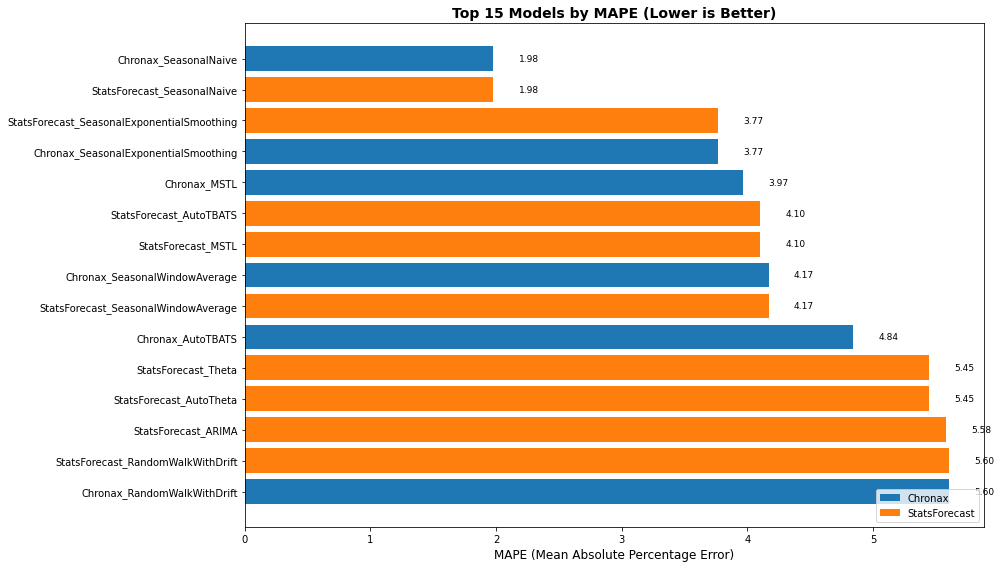

In [12]:
plot_mape_comparison(df, top_n=15)
plt.show()

### 5.2 Performance Comparison (Cold vs Warm)

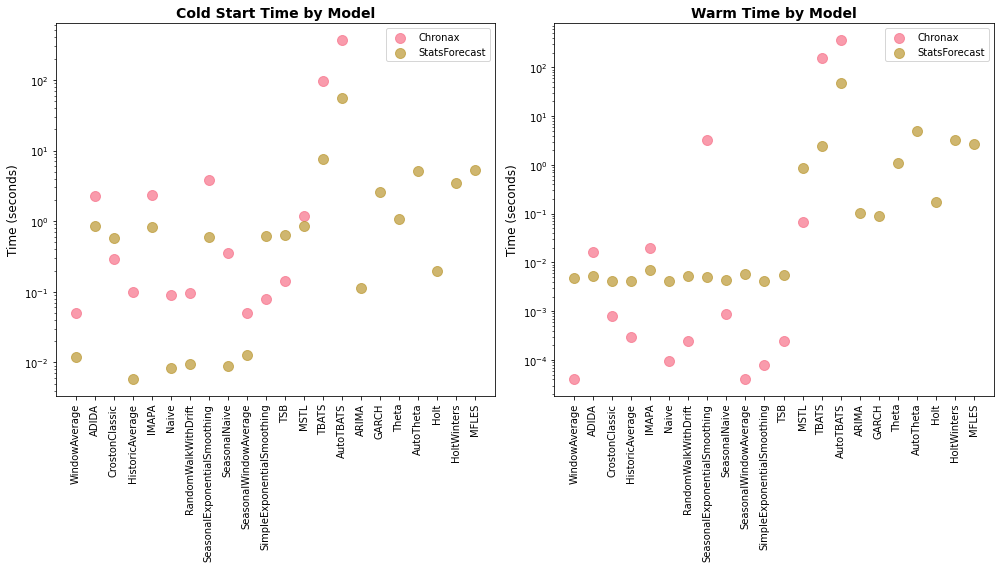

In [13]:
plot_performance_comparison(df)
plt.show()

### 5.3 Library Comparison Overview

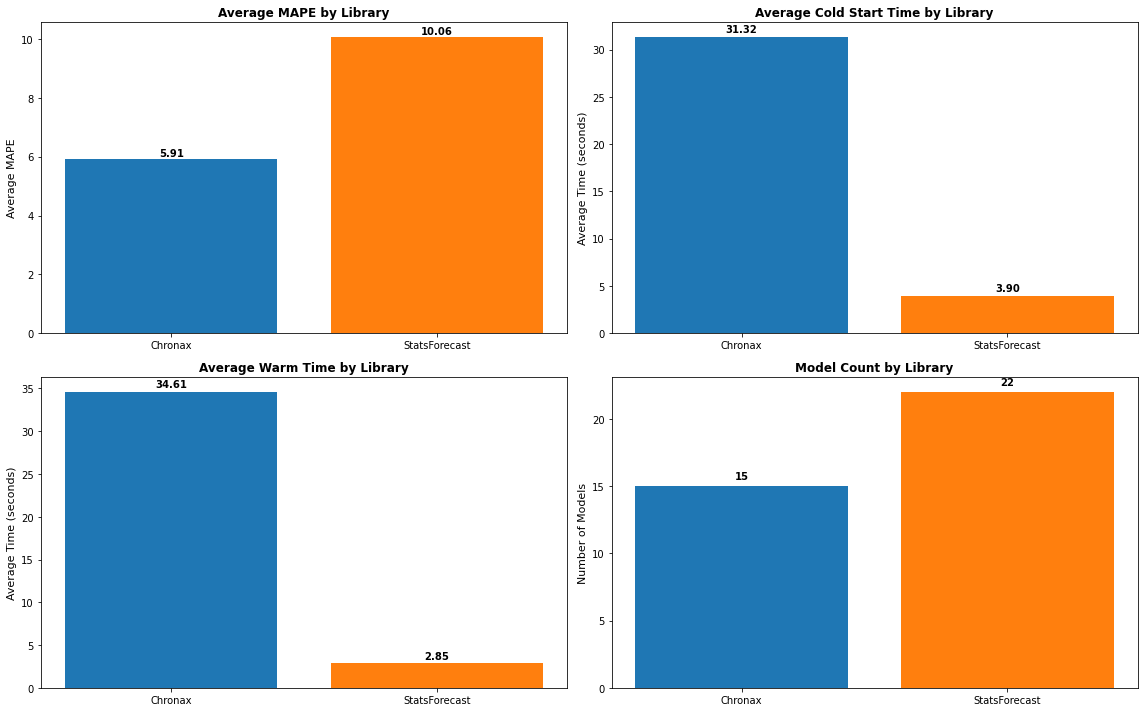

In [30]:
plot_library_comparison(df)
plt.show()

### 5.4 Accuracy vs Speed Trade-off

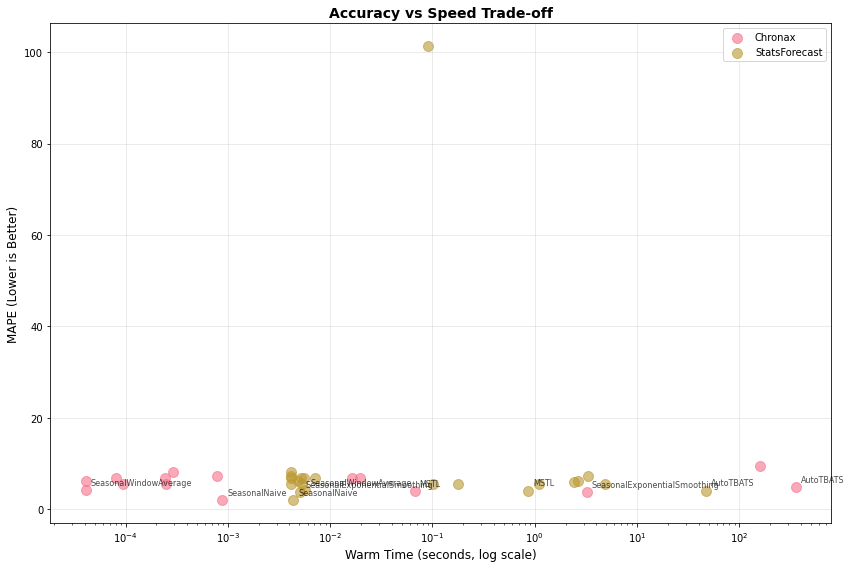

In [31]:
plot_accuracy_vs_speed(df)
plt.show()

### 5.5 Heatmap Comparison

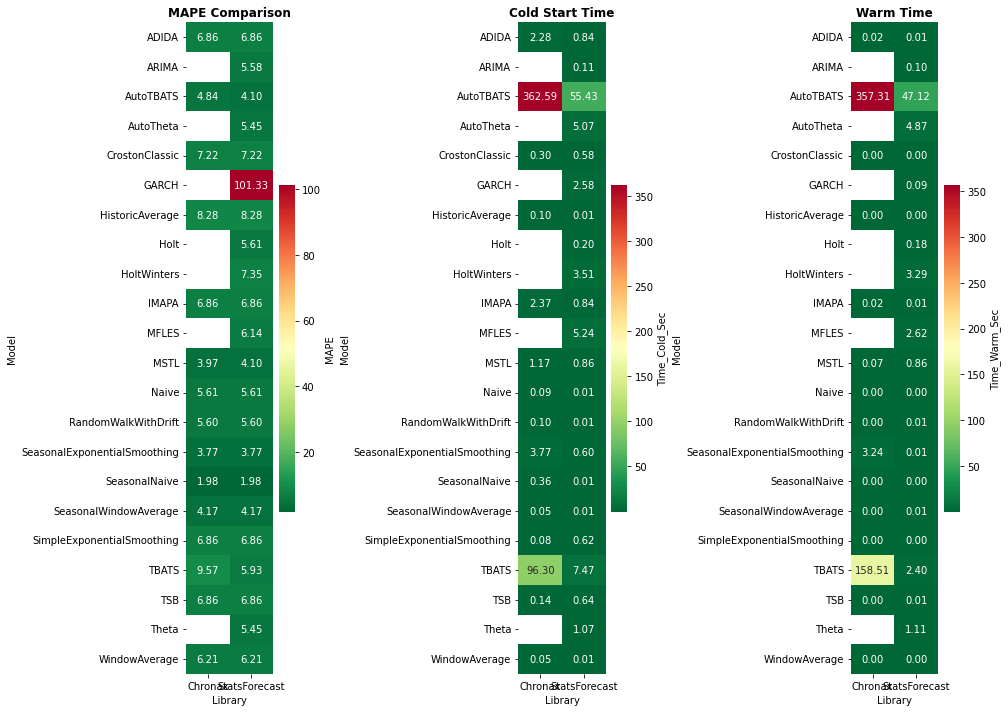

In [32]:
plot_heatmap_comparison(df)
plt.show()

## 6. Additional Analysis

### 6.1 Best Models by Library

In [33]:
print("\nTop 5 Models by Library (Lowest MAPE):")
print("="*80)
for library in df['Library'].unique():
    print(f"\n{library}:")
    top_5 = df[df['Library'] == library].nsmallest(5, 'MAPE')[['Model', 'MAPE', 'Time_Warm_Sec']]
    print(top_5.to_string(index=False))


Top 5 Models by Library (Lowest MAPE):

Chronax:
                               Model     MAPE  Time_Warm_Sec
               Chronax_SeasonalNaive 1.979088       0.000881
Chronax_SeasonalExponentialSmoothing 3.768266       3.238666
                        Chronax_MSTL 3.966668       0.066895
       Chronax_SeasonalWindowAverage 4.170409       0.000041
                   Chronax_AutoTBATS 4.839995     357.314611

StatsForecast:
                                     Model     MAPE  Time_Warm_Sec
               StatsForecast_SeasonalNaive 1.979088       0.004355
StatsForecast_SeasonalExponentialSmoothing 3.768266       0.005075
                   StatsForecast_AutoTBATS 4.101400      47.116951
                        StatsForecast_MSTL 4.103740       0.864330
       StatsForecast_SeasonalWindowAverage 4.170409       0.005713


### 6.2 Statistical Comparison

In [34]:
print("\nStatistical Comparison by Library:")
print("="*80)
comparison = df.groupby('Library')[['MAPE', 'Time_Cold_Sec', 'Time_Warm_Sec']].agg(['mean', 'median', 'std'])
print(comparison)


Statistical Comparison by Library:
                    MAPE                      Time_Cold_Sec            \
                    mean    median        std          mean    median   
Library                                                                 
Chronax         5.911003  6.213382   1.938608     31.317062  0.295972   
StatsForecast  10.060562  5.771009  20.435482      3.895317  0.629198   

                         Time_Warm_Sec                       
                     std          mean    median        std  
Library                                                      
Chronax        94.892664     34.611011  0.000790  98.139724  
StatsForecast  11.692255      2.850259  0.006426   9.977418  
